# Machine Learning Assignment  -2
# Student ID :  2025AA05921
# Name : Kamaraj

# Loan Approval Classification - Model - 4- Naive Bayes

In [1]:
# Import the required libraries 
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns  
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV 
from sklearn.preprocessing import LabelEncoder  
from sklearn.naive_bayes import GaussianNB  
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix, classification_report, roc_curve  # Evaluation metrics
import warnings 
warnings.filterwarnings('ignore') 
import os 
import joblib

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(f"Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Step 1: Data Loading
# Read the dataset
train_data = pd.read_csv('../data/train_data.csv')
test_data = pd.read_csv('../data/test_data.csv')

print(f"Training data loaded: {train_data.shape}")
print(f"Test data loaded: {test_data.shape}")

# Combine for initial exploration
df_raw = pd.concat([train_data, test_data], ignore_index=True)

print(f"\nCombined dataset shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print("\nFirst few rows:")
print(df_raw.head())


Training data loaded: (33750, 14)
Test data loaded: (11250, 14)

Combined dataset shape: (45000, 14)
Columns: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']

First few rows:
   person_age person_gender person_education  person_income  person_emp_exp  \
0        26.0        female        Associate       102675.0               5   
1        24.0          male         Bachelor        84036.0               0   
2        24.0        female         Bachelor        68237.0               2   
3        25.0        female        Associate        69530.0               0   
4        37.0        female        Associate       120992.0              12   

  person_home_ownership  loan_amnt        loan_intent  loan_int_rate  \
0              MORTGAGE     6000.0          EDUCATI

In [3]:
# Step 2:  EDA 
print("Dataset Information:")
print(df_raw.info())

print("\nTarget Variable Distribution:")
print(df_raw['loan_status'].value_counts())
print(f"Class Balance: {df_raw['loan_status'].value_counts(normalize=True).round(4)}") # Class  Distribution

print("\nMissing Values:")
print(df_raw.isnull().sum()) # Ensures that we have no missing values in the dataset

print("\nBasic Statistics:")
print(df_raw.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_lo

In [4]:
# Step 3: Categorical Encoding

df = df_raw.copy()  # Keep original safe

categorical_cols = [  # Categorical columns to encode
    'person_gender',
    'person_education', 
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

# Store label encoders for each categorical column
label_encoders = {}

for col in categorical_cols:  # Encode each categorical column
    if col in df.columns:
        print(f"Encoding {col}:")
        print(f"  Original values: {df[col].unique()}")
        
        le = LabelEncoder()  # Label encoder instance
        df[col] = le.fit_transform(df[col].astype(str))  # Map categories to integers
        label_encoders[col] = le  # Store the encoder
        
        print(f"  Encoded values: {df[col].unique()}")


Encoding person_gender:
  Original values: ['female' 'male']
  Encoded values: [0 1]
Encoding person_education:
  Original values: ['Associate' 'Bachelor' 'High School' 'Master' 'Doctorate']
  Encoded values: [0 1 3 4 2]
Encoding person_home_ownership:
  Original values: ['MORTGAGE' 'RENT' 'OWN' 'OTHER']
  Encoded values: [0 3 2 1]
Encoding loan_intent:
  Original values: ['EDUCATION' 'DEBTCONSOLIDATION' 'MEDICAL' 'HOMEIMPROVEMENT' 'VENTURE'
 'PERSONAL']
  Encoded values: [1 0 3 2 5 4]
Encoding previous_loan_defaults_on_file:
  Original values: ['No' 'Yes']
  Encoded values: [0 1]


In [5]:
# Step 4: Feature and Target Separation

X = df.drop('loan_status', axis=1)  # Features
y = df['loan_status']  # Target


print(f"Feature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"Features: {list(X.columns)}")
print(f"Target classes: {y.unique()}")
print(f"Target distribution: {y.value_counts().to_dict()}")


Feature matrix X shape: (45000, 13)
Target vector y shape: (45000,)
Features: ['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']
Target classes: [0 1]
Target distribution: {0: 35000, 1: 10000}


In [6]:
# Step 5: Encode Categorical Features

# Separate features and target from training data
X_train = train_data.drop('loan_status', axis=1).copy()
y_train = train_data['loan_status']

# Separate features and target from test data
X_test = test_data.drop('loan_status', axis=1).copy()
y_test = test_data['loan_status']

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)")
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

# Encode categorical features in training and test data
categorical_cols = [
    'person_gender',
    'person_education',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

label_encoders = {}
for col in categorical_cols:
    if col in X_train.columns:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
        label_encoders[col] = le


print("\nClass distribution in training set:")
print(y_train.value_counts())
print(f"Training class balance: {y_train.value_counts(normalize=True).round(4)}")

print("\nClass distribution in test set:")
print(y_test.value_counts())
print(f"Test class balance: {y_test.value_counts(normalize=True).round(4)}")


Training set: 33750 samples (75.0%)
Test set: 11250 samples (25.0%)
Training features shape: (33750, 13)
Test features shape: (11250, 13)

Class distribution in training set:
loan_status
0    26250
1     7500
Name: count, dtype: int64
Training class balance: loan_status
0    0.7778
1    0.2222
Name: proportion, dtype: float64

Class distribution in test set:
loan_status
0    8750
1    2500
Name: count, dtype: int64
Test class balance: loan_status
0    0.7778
1    0.2222
Name: proportion, dtype: float64


In [7]:
# Step 6: Hyperparameter Tuning - Naive Bayes Parameters
print("Hyperparameter Tuning:")

# Test different smoothing values
smoothing_values = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
cv_scores = []

print("Testing var_smoothing values (5-fold cross-validation):")
print("Smoothing\tMean CV Accuracy\tStd Dev")
print("-" * 45)

for smoothing in smoothing_values:
    nb = GaussianNB(var_smoothing=smoothing)
    scores = cross_val_score(nb, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f"{smoothing}\t\t{scores.mean():.4f}\t\t{scores.std():.4f}")

# Find best smoothing value
best_smoothing = smoothing_values[np.argmax(cv_scores)]
best_score = max(cv_scores)

print(f"Best var_smoothing: {best_smoothing}")
print(f"Best CV accuracy: {best_score:.4f}")


Hyperparameter Tuning:
Testing var_smoothing values (5-fold cross-validation):
Smoothing	Mean CV Accuracy	Std Dev
---------------------------------------------
1e-09		0.8118		0.0065
1e-08		0.7846		0.0023
1e-07		0.7821		0.0022
1e-06		0.7819		0.0022
1e-05		0.7819		0.0020
0.0001		0.7817		0.0017
0.001		0.7816		0.0023
Best var_smoothing: 1e-09
Best CV accuracy: 0.8118


In [8]:
# Step 7: Model Training -  Naive Bayes Model

print("Training Naive Bayes Model:")

# Create and train the final model
nb_final = GaussianNB(var_smoothing=best_smoothing)

nb_final.fit(X_train, y_train)

print(f"Naive Bayes Model Training Complete!")
print(f"Model Parameters:")
print(f"   - Algorithm: Gaussian Naive Bayes")
print(f"   - var_smoothing: {best_smoothing}")
print(f"   - Prior probabilities: {nb_final.class_prior_}")
print(f"Training Set Size: {X_train.shape[0]} samples")
print(f"Number of Features: {X_train.shape[1]}")

train_accuracy = nb_final.score(X_train, y_train)
print(f" Training Accuracy: {train_accuracy:.4f}")

# Show class prior probabilities
print(f"\nClass Prior Probabilities:")
for i, class_label in enumerate(nb_final.classes_):
    print(f"  Class {class_label}: {nb_final.class_prior_[i]:.4f}")


Training Naive Bayes Model:
Naive Bayes Model Training Complete!
Model Parameters:
   - Algorithm: Gaussian Naive Bayes
   - var_smoothing: 1e-09
   - Prior probabilities: [0.77777778 0.22222222]
Training Set Size: 33750 samples
Number of Features: 13
 Training Accuracy: 0.8127

Class Prior Probabilities:
  Class 0: 0.7778
  Class 1: 0.2222


In [9]:
# Step 8: Model Predictions

y_pred = nb_final.predict(X_test)

# Generate prediction probabilities
y_pred_proba = nb_final.predict_proba(X_test)

print(f" Test Set Size: {len(y_test)} samples")
print(f" Predictions Generated: {len(y_pred)}")

# Show prediction summary
unique_preds, pred_counts = np.unique(y_pred, return_counts=True)
print(f"\nPrediction Distribution:")
print("Class\tCount\tPercentage")
print("-" * 25)
for class_val, count in zip(unique_preds, pred_counts):
    percentage = (count / len(y_pred)) * 100
    print(f"{class_val}\t{count}\t{percentage:.1f}%")



 Test Set Size: 11250 samples
 Predictions Generated: 11250

Prediction Distribution:
Class	Count	Percentage
-------------------------
0	10198	90.6%
1	1052	9.4%


In [10]:
# Step 9: C Evaluation Metrics 

print("NAIVE BAYES MODEL EVALUATION METRICS")
print("=" * 55)

# 1. Accuracy
accuracy = accuracy_score(y_test, y_pred)

# 2. AUC (Area Under ROC Curve)
auc = roc_auc_score(y_test, y_pred_proba[:, 1])

# 3. Precision
precision = precision_score(y_test, y_pred)

# 4. Recall
recall = recall_score(y_test, y_pred)

# 5. F1-Score
f1 = f1_score(y_test, y_pred)

# 6. MCC (Matthews Correlation Coefficient)
mcc = matthews_corrcoef(y_test, y_pred)

# Metric Summary
print(f"1. Accuracy:  {accuracy:.4f}")
print(f"2. AUC:       {auc:.4f}")
print(f"3. Precision: {precision:.4f}")
print(f"4. Recall:    {recall:.4f}")
print(f"5. F1-Score:  {f1:.4f}")
print(f"6. MCC:       {mcc:.4f}")


NAIVE BAYES MODEL EVALUATION METRICS
1. Accuracy:  0.8132
2. AUC:       0.7920
3. Precision: 0.6892
4. Recall:    0.2900
5. F1-Score:  0.4082
6. MCC:       0.3607


In [11]:
# Step 10
# Classification Report
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX")
print("-" * 30)
print("Actual\\Predicted    0     1")
print(f"0 (Rejected)     {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"1 (Approved)     {cm[1,0]:4d}  {cm[1,1]:4d}")

# Calculate True/False Positives/Negatives
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Component values:")
print("-" * 30)
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")  
print(f"True Positives (TP):  {tp}")



CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      8750
           1       0.69      0.29      0.41      2500

    accuracy                           0.81     11250
   macro avg       0.76      0.63      0.65     11250
weighted avg       0.80      0.81      0.78     11250


CONFUSION MATRIX
------------------------------
Actual\Predicted    0     1
0 (Rejected)     8423   327
1 (Approved)     1775   725

Confusion Matrix Component values:
------------------------------
True Negatives (TN):  8423
False Positives (FP): 327
False Negatives (FN): 1775
True Positives (TP):  725



CREATING MODEL VISUALIZATIONS


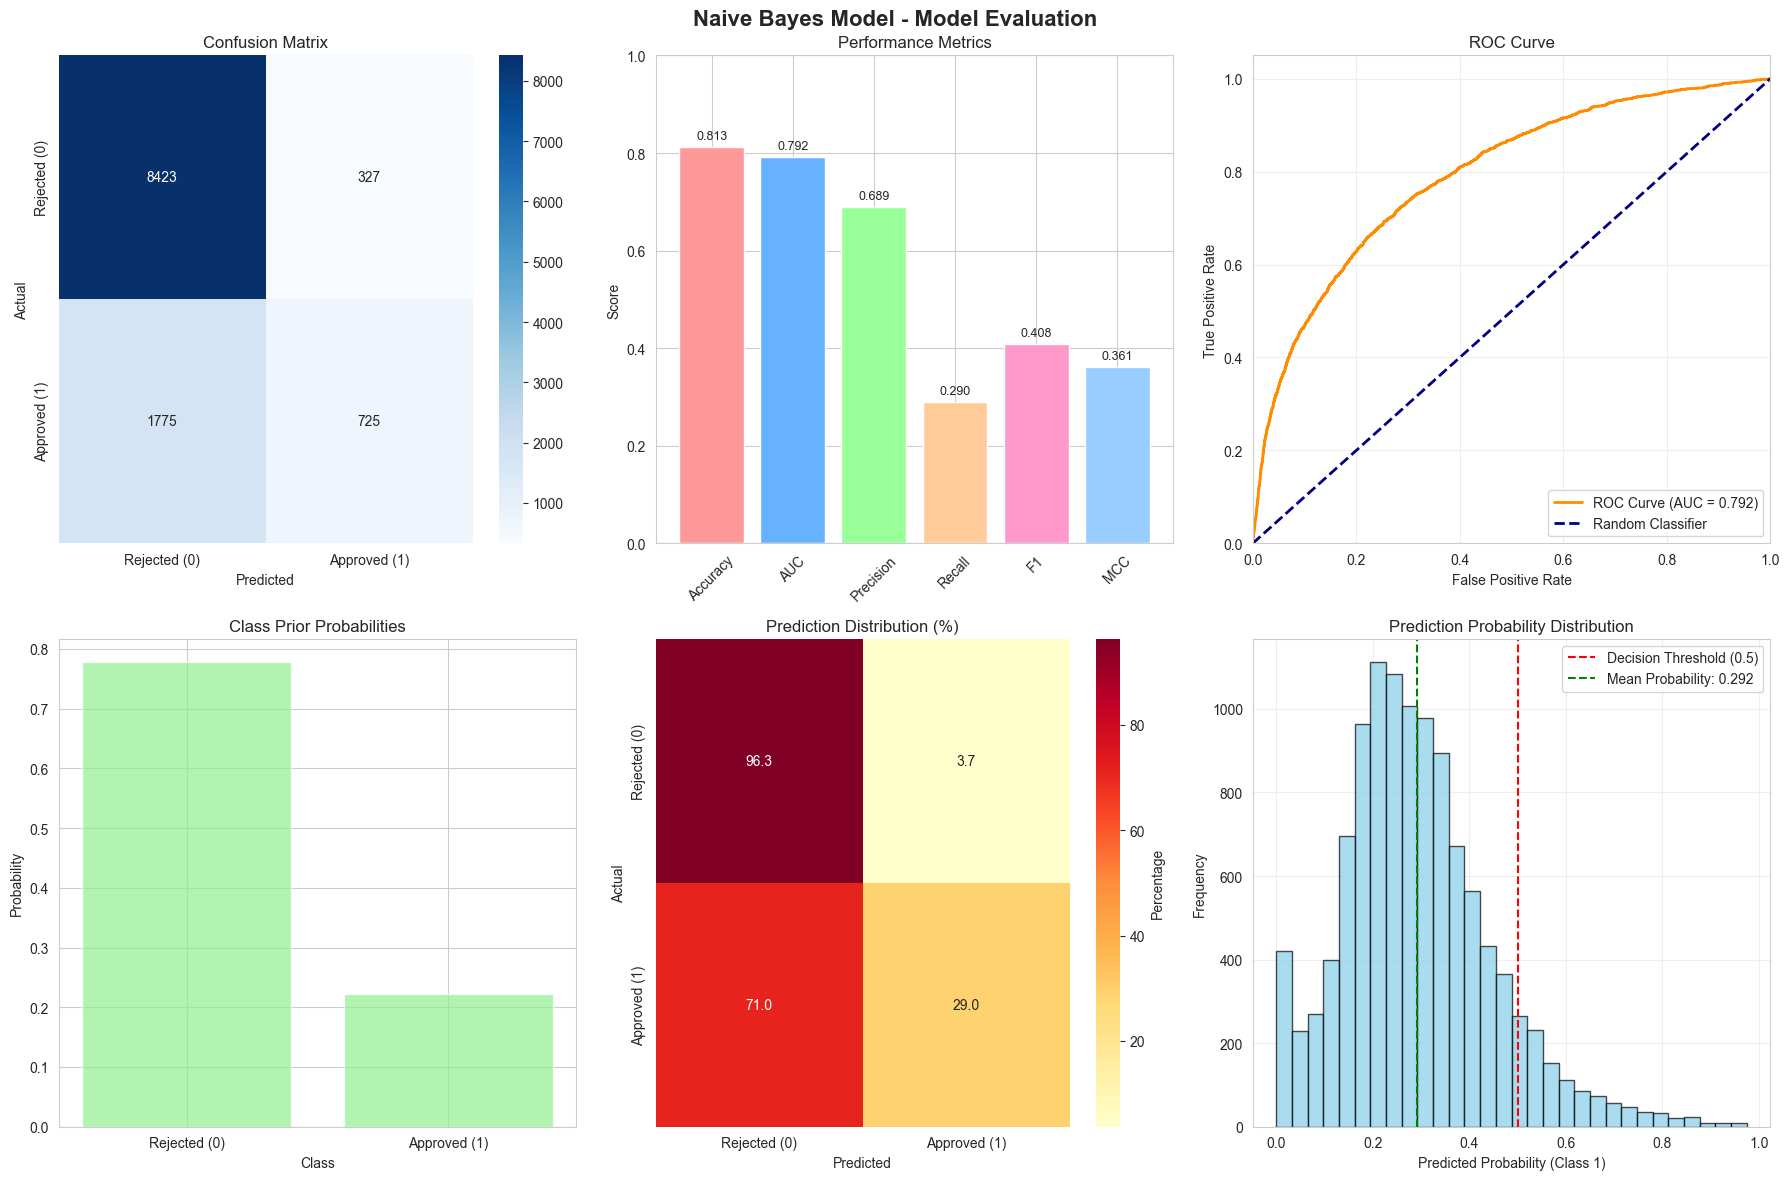

In [12]:
# Step 11
# Model Visualizations
print("\nCREATING MODEL VISUALIZATIONS")
print("=" * 50)

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Naive Bayes Model - Model Evaluation', fontsize=16, fontweight='bold')

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'], ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xlabel('Predicted')

# 2. Metrics Comparison
metrics_names = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']
metrics_values = [accuracy, auc, precision, recall, f1, mcc]
bars = axes[0,1].bar(metrics_names, metrics_values, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC', '#99CCFF'])
axes[0,1].set_title('Performance Metrics')
axes[0,1].set_ylabel('Score')
axes[0,1].set_ylim(0, 1)
axes[0,1].tick_params(axis='x', rotation=45)
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0,1].text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{metrics_values[i]:.3f}', 
                   ha='center', va='bottom', fontsize=9)

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
axes[0,2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
axes[0,2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0,2].set_xlim([0.0, 1.0])
axes[0,2].set_ylim([0.0, 1.05])
axes[0,2].set_xlabel('False Positive Rate')
axes[0,2].set_ylabel('True Positive Rate')
axes[0,2].set_title('ROC Curve')
axes[0,2].legend(loc="lower right")
axes[0,2].grid(True, alpha=0.3)

# 4. Class Prior Probabilities
classes = nb_final.classes_
priors = nb_final.class_prior_
axes[1,0].bar(classes, priors, color='lightgreen', alpha=0.7)
axes[1,0].set_title('Class Prior Probabilities')
axes[1,0].set_xlabel('Class')
axes[1,0].set_ylabel('Probability')
axes[1,0].set_xticks(classes)
axes[1,0].set_xticklabels(['Rejected (0)', 'Approved (1)'])

# 5. Prediction Distribution
pred_df = pd.DataFrame({'Actual': y_test.values if hasattr(y_test, 'values') else y_test, 'Predicted': y_pred})
pred_crosstab = pd.crosstab(pred_df['Actual'], pred_df['Predicted'], normalize='index') * 100
sns.heatmap(pred_crosstab, annot=True, fmt='.1f', cmap='YlOrRd', 
            xticklabels=['Rejected (0)', 'Approved (1)'], 
            yticklabels=['Rejected (0)', 'Approved (1)'], ax=axes[1,1], cbar_kws={'label': 'Percentage'})
axes[1,1].set_title('Prediction Distribution (%)')
axes[1,1].set_ylabel('Actual')
axes[1,1].set_xlabel('Predicted')

# 6. Prediction Probability Distribution
y_prob = y_pred_proba[:, 1]
axes[1,2].hist(y_prob, bins=30, color='skyblue', alpha=0.7, edgecolor='black')
axes[1,2].axvline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
axes[1,2].axvline(np.mean(y_prob), color='green', linestyle='--', label=f'Mean Probability: {np.mean(y_prob):.3f}')
axes[1,2].set_title('Prediction Probability Distribution')
axes[1,2].set_xlabel('Predicted Probability (Class 1)')
axes[1,2].set_ylabel('Frequency')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
# Step 12: Results Summary 

print("MODEL: Gaussian Naive Bayes Classifier")
print(f"SMOOTHING Value: {best_smoothing}")

print("\nEvaluation Metrics Summary:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"AUC:       {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")


MODEL: Gaussian Naive Bayes Classifier
SMOOTHING Value: 1e-09

Evaluation Metrics Summary:
Accuracy:  0.8132
AUC:       0.7920
Precision: 0.6892
Recall:    0.2900
F1-Score:  0.4082
MCC:       0.3607


In [14]:
# Step 13: Save Model to JOBLIB File

# Save the  model
model_path = '../model/4_naive_bayes_model.joblib'
joblib.dump(nb_final, model_path)
print(f"Model saved to: {model_path}")

# Save label encoders
encoders_path = '../model/4_naive_bayes_encoders.joblib'
joblib.dump(label_encoders, encoders_path)
print(f"Label encoders saved to: {encoders_path}")

Model saved to: ../model/4_naive_bayes_model.joblib
Label encoders saved to: ../model/4_naive_bayes_encoders.joblib
